In [3]:
!pip3 install keras-visualizer

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras_visualizer import visualizer
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x_data = [[0,0], [1,0],[0,1],[1,1]]
y_data = [[0],[1],[1],[0]]

In [6]:
model = keras.Sequential(
    [
        layers.Dense(2,activation="sigmoid",name="layer1", input_shape=(2,)),
        layers.Dense(1,activation="sigmoid",name="output")

    ]
)

In [7]:
visualizer(model, filename="graph01", format="png", view=True)

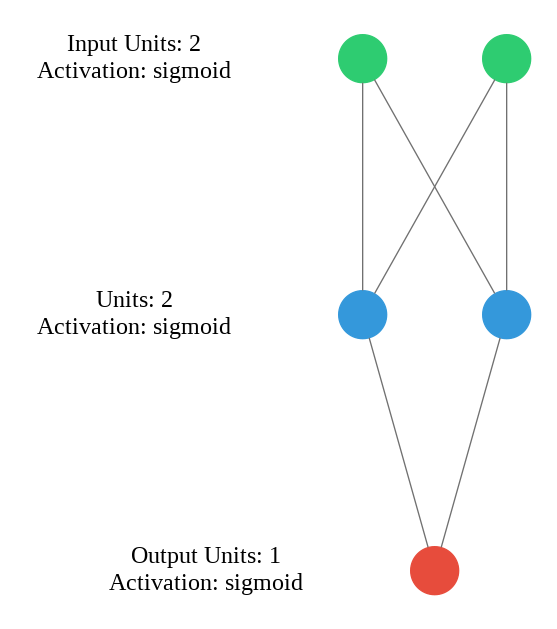

In [8]:
from PIL import Image
input_path="graph01.png"
im = Image.open(input_path)
im

In [9]:
#Usamos learning rate de 1 para obtener un loss menor a 0.1
optimizer = keras.optimizers.SGD(lr=1)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=("accuracy"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer1 (Dense)              (None, 2)                 6         
                                                                 
 output (Dense)              (None, 1)                 3         
                                                                 
Total params: 9
Trainable params: 9
Non-trainable params: 0
_________________________________________________________________


/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


In [11]:
model.fit(x_data, y_data, epochs=1000)
loss = model.history.history['loss']

Epoch 1/1000
1/1 [==============================] - 2s 2s/step - loss: 0.7445 - accuracy: 0.5000
Epoch 2/1000
1/1 [==============================] - 0s 35ms/step - loss: 0.7135 - accuracy: 0.5000
Epoch 3/1000
1/1 [==============================] - 0s 21ms/step - loss: 0.7016 - accuracy: 0.5000
Epoch 4/1000
1/1 [==============================] - 0s 41ms/step - loss: 0.6971 - accuracy: 0.5000
Epoch 5/1000
1/1 [==============================] - 0s 46ms/step - loss: 0.6954 - accuracy: 0.5000
Epoch 6/1000
1/1 [==============================] - 0s 39ms/step - loss: 0.6947 - accuracy: 0.5000
Epoch 7/1000
1/1 [==============================] - 0s 34ms/step - loss: 0.6944 - accuracy: 0.5000
Epoch 8/1000
1/1 [==============================] - 0s 49ms/step - loss: 0.6942 - accuracy: 0.5000
Epoch 9/1000
1/1 [==============================] - 0s 31ms/step - loss: 0.6941 - accuracy: 0.5000
Epoch 10/1000
1/1 [==============================] - 0s 32ms/step - loss: 0.6941 - accuracy: 0.5000
Epoch 11/10

<function matplotlib.pyplot.show(*args, **kw)>

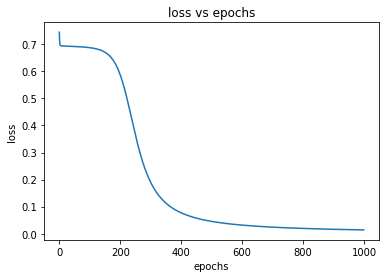

In [12]:
plt.plot(loss)
plt.title('loss vs epochs')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show

In [13]:
weights = model.get_weights()
weights
#El array 1 son los pesos de la primera capa ([-6.950871 ,  6.3309417],[ 6.742714 , -6.6271324])
#El array 2 es el bias ([-3.6972811, -3.4589987])
#El array 3 son los pesos de la segunda capa ([11.400289],[11.482855])
#El array 4 es el bias de la segunda capa ([-5.6164484])

[array([[-6.15975  , -6.025293 ],
        [ 5.9436755,  6.279436 ]], dtype=float32),
 array([-3.1991022,  3.0113773], dtype=float32),
 array([[10.143033],
        [-9.583214]], dtype=float32),
 array([4.4431987], dtype=float32)]

In [14]:
first_layer_weights = model.layers[0].get_weights()[0]
first_layer_biases  = model.layers[0].get_weights()[1]
second_layer_weights = model.layers[1].get_weights()[0]
second_layer_biases  = model.layers[1].get_weights()[1]


In [15]:
FLW = model.layers[0].get_weights()[0]
FLB  = model.layers[0].get_weights()[1]
SLW = model.layers[1].get_weights()[0]
SLB  = model.layers[1].get_weights()[1]

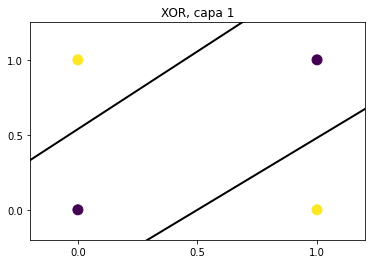

In [19]:
 # Now plot the fitted line. We need only two points to plot the line
x=np.array([[0,0,0],[1,0,1],[1,1,0],[0,1,1]])

plot_x = np.array([np.min(x[:, 0] - 0.2), np.max(x[:, 1]+0.2)])
plot_y =  -1 / first_layer_weights[1, 0] * (first_layer_weights[0, 0] * plot_x + first_layer_biases[0])
plot_y = np.reshape(plot_y, [2, -1])
plot_y = np.squeeze(plot_y)

plot_y2 = -1 / first_layer_weights[1, 1] * (first_layer_weights[0, 1] * plot_x + first_layer_biases[1])
plot_y2 = np.reshape(plot_y2, [2, -1])
plot_y2 = np.squeeze(plot_y2)

plt.scatter(x[:,0],x[:,1],c=x[:,2],s=100)
plt.plot(plot_x, plot_y, color='k', linewidth=2)    # line 1
plt.plot(plot_x, plot_y2, color='k', linewidth=2)   # line 2
plt.xlim([-0.2, 1.2]); plt.ylim([-0.2, 1.25]);
plt.title("XOR, capa 1")
plt.xticks([0.0, 0.5, 1.0]); plt.yticks([0.0, 0.5, 1.0])
plt.show()

In [1]:
# Now plot the fitted line. We need only two points to plot the line
x2=np.array([[0,0,0],[1,0,1],[1,1,0],[0,1,1]])

plot_2x = np.array([np.min(x2[:, 0] - 0.2), np.max(x2[:, 1]+0.2)])
plot_2y =  -1 / second_layer_weights[1, 0] * (second_layer_weights[0, 0] * plot_2x + second_layer_biases[0])

plt.scatter(x2[:,0],x2[:,1],c=x2[:,2],s=100)
plt.plot(plot_2x, plot_2y, color='k', linewidth=2)    # line 1
plt.xlim([-0.2, 1.2]); plt.ylim([-0.2, 1.25]);
plt.title("XOR, capa 2")
plt.xticks([0.0, 0.5, 1.0]); plt.yticks([0.0, 0.5, 1.0])
plt.show()

NameError: ignored